# PCA Baseline on Synthetic Multivariate Outliers

This notebook mirrors the LOF benchmark in `ml_04_lof_baseline_synthetic.ipynb`, but swaps the detector for a **Principal Component Analysis (PCA)** outlier model from OSBAD. The same synthetic multivariate dataset is reused so the baselines can be compared on identical ground truth.

Beyond the Severson and Tohoku battery datasets used elsewhere in this project, the synthetic dataset is not tied to any specific battery chemistry or application. Reusing it here demonstrates that OSBAD generalizes across detectors: because the PCA model operates on generic feature vectors, the same workflow can be applied to entirely new chemistries and applications without modification.

The workflow is:

* **Load synthetic data:** read the pre-generated 2D dataset from `multivariate_dataset.csv` and recover the ground-truth outlier labels from the known injected coordinates.
* **Detect outliers:** run a **PCA** baseline (no hyperparameter tuning) through the OSBAD `ModelRunner`, which returns a probabilistic outlier score per sample.
* **Evaluate:** compare the predicted outliers against the injected ground truth with a confusion matrix and the standard OSBAD evaluation metrics.

Since the injected outliers are known in advance, they serve as the ground-truth labels for benchmarking the PCA detector.

# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.viz as bviz
from osbad.model import ModelRunner

# Load the Synthetic Multivariate Dataset

The dataset generated in `ml_01_iforest_baseline_synthetic.ipynb` is loaded from `multivariate_dataset.csv`. It contains 207 samples with an `index`, `feature_1`, and `feature_2` column.

Because the CSV does not store the labels, the ground-truth outliers are recovered by matching the known injected outlier coordinates against the loaded rows. Their `index` values (`true_outlier_index`) then serve as the ground-truth labels for evaluating the PCA detector.

In [2]:
# Load the pre-generated synthetic dataset
df_multivariate = pd.read_csv("multivariate_dataset.csv")

# The known outlier coordinates injected when the dataset was created
injected_outliers = np.array([
    [10, 12],
    [90, 88],
    [5, 95],
    [95, 8],
    [15, 90],
    [88, 15],
    [100, 100],
])

# Recover the ground-truth outlier index by matching injected coordinates
features = df_multivariate[["feature_1", "feature_2"]].to_numpy()
is_outlier_mask = np.any(
    np.all(features[:, None, :] == injected_outliers[None, :, :], axis=2),
    axis=1)

true_outlier_index = df_multivariate.loc[
    is_outlier_mask, "index"].to_numpy()

print(f"Number of samples: {df_multivariate.shape[0]}")
print(f"Number of injected outliers: {true_outlier_index.size}")
print(f"Injected outlier index: {true_outlier_index.tolist()}")
df_multivariate.describe()

Number of samples: 207
Number of injected outliers: 7
Injected outlier index: [103, 124, 144, 154, 176, 182, 197]


,index,feature_1,feature_2
count,207.000000,207.000000,207.000000
mean,103.000000,50.362531,50.123589
std,59.899917,9.152865,8.862541
min,0.000000,5.000000,8.000000
25%,51.500000,46.763652,46.425252
50%,103.000000,50.332729,49.756408
75%,154.500000,53.452168,52.823441
max,206.000000,100.000000,100.000000


## Plot the synthetic dataset

The scatterplot shows the compact inlier cluster (tomato) with the injected multivariate outliers (crimson crosses) scattered around the edges of the feature space.

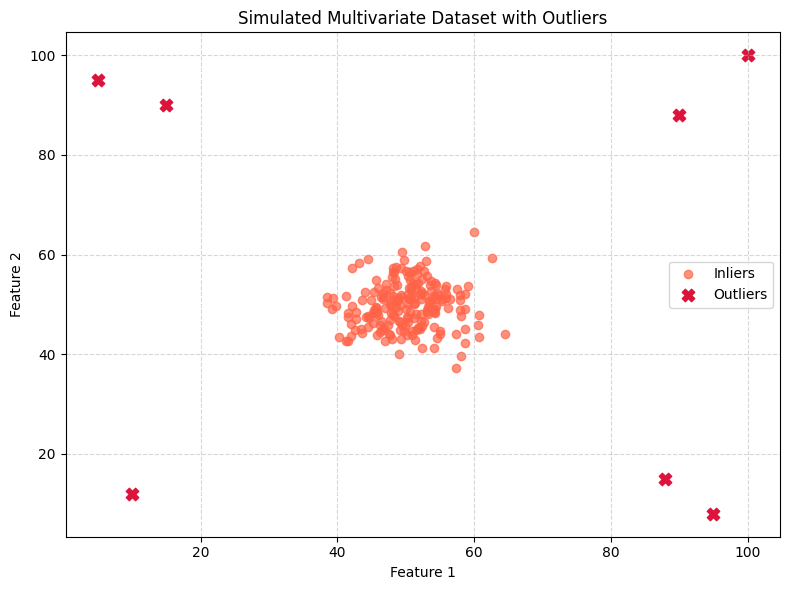

In [3]:
# Plot the multivariate dataset, highlighting the injected outliers
is_outlier = df_multivariate["index"].isin(true_outlier_index)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.rcParams.update(mpl.rcParamsDefault)

ax.scatter(
    df_multivariate.loc[~is_outlier, "feature_1"],
    df_multivariate.loc[~is_outlier, "feature_2"],
    color="tomato",
    label="Inliers",
    alpha=0.7)
ax.scatter(
    df_multivariate.loc[is_outlier, "feature_1"],
    df_multivariate.loc[is_outlier, "feature_2"],
    color="crimson",
    label="Outliers",
    marker="X",
    s=80)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Simulated Multivariate Dataset with Outliers")
ax.legend()
plt.tight_layout()
plt.show()

# PCA without hyperparameter tuning

The PCA outlier detector projects the data onto its principal components and scores each sample by its reconstruction error along those axes: points that deviate strongly from the dominant variance structure receive higher anomaly scores. Here the two synthetic features are used directly as model inputs through the OSBAD `ModelRunner`.

In [4]:
# Label used to organize the figure output for this synthetic dataset
selected_cell_label = "synthetic_multivariate"

# Create a subfolder to store fig output
selected_cell_artifacts_dir = bconf.artifacts_output_dir(
    selected_cell_label)

# Use both synthetic features as model inputs
selected_feature_cols = (
    "feature_1",
    "feature_2")

# Instantiate ModelRunner with selected features and label
runner = ModelRunner(
    cell_label=selected_cell_label,
    df_input_features=df_multivariate,
    selected_feature_cols=selected_feature_cols
)

## Create Xdata for training

In [5]:
# create Xdata array
Xdata = runner.create_model_x_input()

## Fit the model

In [6]:
cfg = hp.MODEL_CONFIG["pca"]

# create model instance without hyperparameter tuning
model = cfg.baseline_model_param()
model.fit(Xdata)

# Predict probabilistic outlier score
proba = model.predict_proba(Xdata)

# Get predicted outlier index and score from
# the probabilistic outlier score
(pred_outlier_indices,
 pred_outlier_score) = runner.pred_outlier_indices_from_proba(
    proba=proba,
    threshold=0.7,
    outlier_col=cfg.proba_col
)

print("Predicted outlier index:")
print(pred_outlier_indices)
print("-"*70)
print("Predicted corresponding outlier score:")
print(pred_outlier_score)

Predicted outlier index:
[103 124 144 154 176 182 197]
----------------------------------------------------------------------
Predicted corresponding outlier score:
[0.74129922 0.9096489  0.72031026 1.         0.89852241 0.99970801
 0.83469794]


In [7]:
# Access the default hyperparameters without tuning
baseline_model_param = model.get_params()
pprint.pp(baseline_model_param)

{'contamination': 0.1,
 'copy': True,
 'iterated_power': 'auto',
 'n_components': 2,
 'n_selected_components': None,
 'random_state': None,
 'standardization': True,
 'svd_solver': 'auto',
 'tol': 0.0,
 'weighted': True,
 'whiten': False}


# Probabilistic outliers prediction

## Predict anomalous samples

In [8]:
df_outliers_pred = df_multivariate[
    df_multivariate["index"]
    .isin(pred_outlier_indices)].copy()

df_outliers_pred["outlier_prob"] = pred_outlier_score
df_outliers_pred

,index,feature_1,feature_2,outlier_prob
103,103,90.0,88.0,0.741299
124,124,10.0,12.0,0.909649
144,144,15.0,90.0,0.720310
154,154,95.0,8.0,1.000000
176,176,5.0,95.0,0.898522
182,182,100.0,100.0,0.999708
197,197,88.0,15.0,0.834698


## Probabilistic anomaly score map

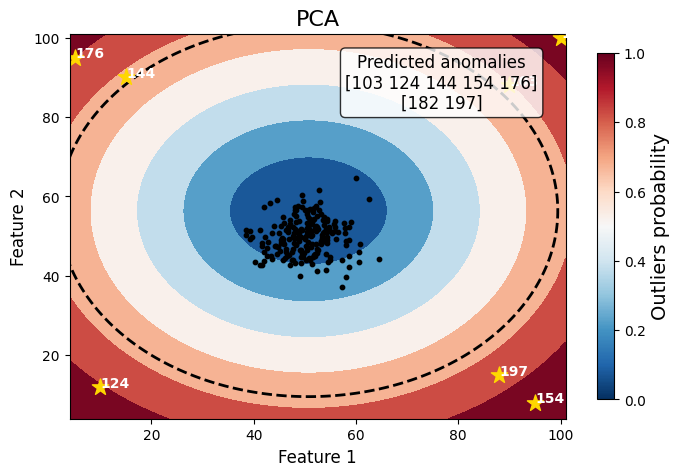

In [9]:
axplot = runner.predict_anomaly_score_map(
    selected_model=model,
    model_name="PCA",
    xoutliers=df_outliers_pred["feature_1"],
    youtliers=df_outliers_pred["feature_2"],
    pred_outliers_index=pred_outlier_indices,
    threshold=0.7,
    annotation_label="Predicted anomalies"
)

axplot.set_xlabel(
    r"Feature 1",
    fontsize=12)
axplot.set_ylabel(
    r"Feature 2",
    fontsize=12)

output_fig_filename = (
    "anomaly_score_map_pca_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Histogram of the anomaly score

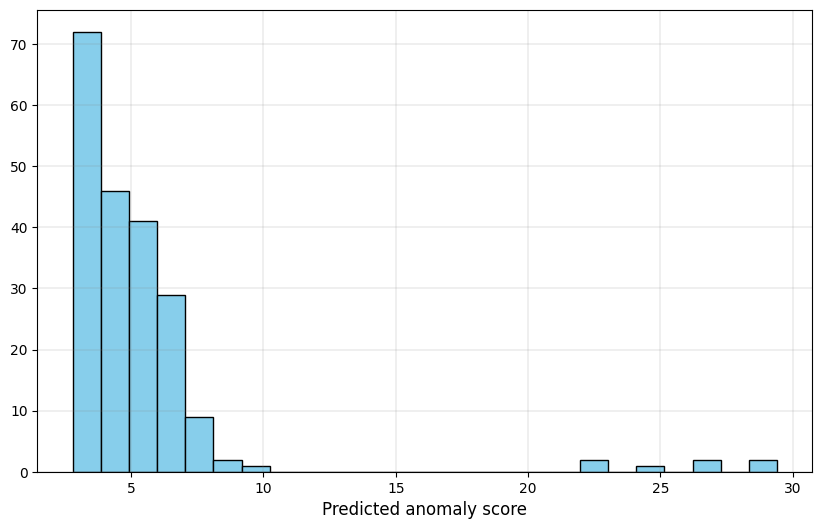

In [10]:
outlier_score = model.decision_function(Xdata)

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    outlier_score,
    color="skyblue",
    edgecolor="black",
    bins=25)

ax.set_xlabel(
    "Predicted anomaly score",
    fontsize=12)

ax.grid(
    color="grey",
    linestyle="-",
    linewidth=0.25,
    alpha=0.7)

plt.show()

In [11]:
# threshold without hyperparameter tuning
model.threshold_

np.float64(6.796718510802334)

# Model performance evaluation

The predicted outliers are compared against the injected ground-truth outliers. Both label vectors are aligned on the sample `index`, following the same evaluation pattern used in the LOF notebook.

In [12]:
# Compare predicted outliers with the true injected outliers
y_true = df_multivariate["index"].isin(true_outlier_index)
y_pred = df_multivariate["index"].isin(pred_outlier_indices)

## Confusion matrix

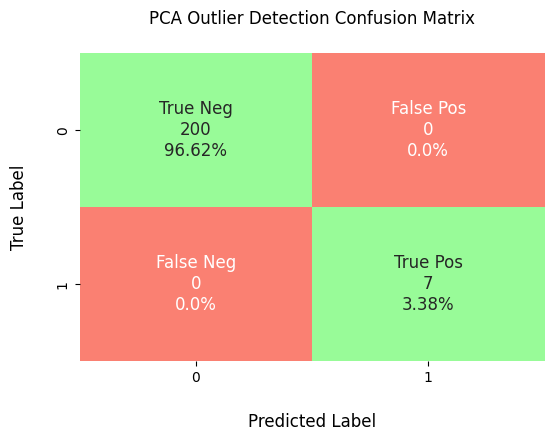

In [13]:
# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

axplot.set_title(
    "PCA Outlier Detection Confusion Matrix"
    + "\n",
    fontsize=12)

output_fig_filename = (
    "conf_matrix_pca_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Evaluation metrics

The model performance is summarized with five metrics: accuracy, precision, recall, F1-score, and the Matthews Correlation Coefficient (MCC).

$$
\textrm{Accuracy} = \frac{\textrm{TP} + \textrm{TN}}{\textrm{Total prediction}}
$$

$$
\textrm{Precision} = \frac{\textrm{TP}}{\textrm{TP + FP}}
$$

$$
\textrm{Recall} = \frac{\textrm{TP}}{\textrm{TP + FN}}
$$

$$
\textrm{F1-score} = \frac{2(\textrm{Precision}\times \textrm{Recall})}{\textrm{Precision} + \textrm{Recall}}
$$

$$
\textrm{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN+FN)}}
$$

In [14]:
# Assemble the per-sample evaluation dataframe
df_eval_outlier = pd.DataFrame({
    "cycle_index": df_multivariate["index"],
    "true_outlier": np.array(y_true, dtype=int),
    "pred_outlier": np.array(y_pred, dtype=int),
})

df_current_eval_metrics = modval.eval_model_performance(
    model_name="pca",
    selected_cell_label=selected_cell_label,
    df_eval_outliers=df_eval_outlier)

df_current_eval_metrics

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
MCC-score: 1.0
****************************************************************************************************


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,pca,synthetic_multivariate,1.0,1.0,1.0,1.0,1.0


In [15]:
# Export current metrics to CSV
metrics_eval_filepath =  Path.cwd().joinpath(
    "eval_metrics_no_hp_synthetic.csv")

hp.export_current_model_metrics(
    model_name="pca",
    selected_cell_label=selected_cell_label,
    df_current_eval_metrics=df_current_eval_metrics,
    export_csv_filepath=metrics_eval_filepath,
    if_exists="replace")

Have the metrics for pca on cell synthetic_multivariate been evaluated before?
True
----------------------------------------------------------------------
Replacing existing row for pca, synthetic_multivariate.
Metrics for pca, synthetic_multivariate have been replaced in the CSV file.


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,autoencoder,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
1,iforest,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
2,knn,synthetic_multivariate,0.990338,1.0,0.714286,0.833333,0.840960
3,gmm,synthetic_multivariate,0.980676,1.0,0.428571,0.600000,0.648204
4,lof,synthetic_multivariate,0.980676,1.0,0.428571,0.600000,0.648204
5,pca,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
